# 07. Entender FinBERT: del texto a las probabilidades

**Autor: Marco Padilla Gómez.** [Issue #49](https://github.com/maarcoopg/tfg-ml-financial-sentiment/issues/49).

Aquí seguimos una noticia por el interior de `ProsusAI/finbert`. No entrenamos un modelo nuevo, no evaluamos todavía su precisión lingüística y no predecimos cotizaciones. Las siguientes tareas separan esas preguntas.

El cuaderno conserva salidas para su lectura. Para ejecutarlo hay que instalar `requirements.txt` y `requirements-finbert.txt` y descargar una vez el checkpoint con `python -m src.nlp.inspect_finbert --download`, desde la raíz. Las celdas solo usan la caché local; no envían noticias a una API. Véase la [guía técnica](../docs/finbert_modelo.md).

## 1. Evidencias y alcance

La ejecución conservada identifica el modelo, las versiones y las huellas de los archivos. Verificamos los resultados antes de leerlos. Un hash identifica unos bytes: no certifica la ausencia de sesgos ni la calidad del entrenamiento.

In [1]:
from pathlib import Path
import hashlib
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'src').is_dir(), 'Ejecuta desde la raíz o desde notebooks/'
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RUN = ROOT / 'reports/experiments/finbert-understanding-20260922'
manifest = json.loads((RUN / 'manifest.json').read_text(encoding='utf-8'))
assert manifest['status'] == 'complete'
for name, digest in manifest['output_sha256'].items():
    assert hashlib.sha256((RUN / name).read_bytes()).hexdigest() == digest, name
display(pd.Series({k: manifest[k] for k in ['model_id', 'revision', 'device', 'parameters', 'checks_passed']}, name='Ejecución'))
display(pd.Series(manifest['versions'], name='Versiones'))

model_id                                 ProsusAI/finbert
revision         4556d13015211d73dccd3fdd39d39232506f3e43
device                                                cpu
parameters                                      109484547
checks_passed                                          28
Name: Ejecución, dtype: object

torch              2.8.0+cpu
transformers          4.57.6
huggingface-hub       0.36.2
tokenizers            0.22.2
safetensors            0.7.0
numpy                  2.2.6
pandas                 2.3.3
matplotlib            3.10.9
Name: Versiones, dtype: object

## 2. De dónde procede su conocimiento

Hay que distinguir **preentrenamiento general**, **adaptación financiera** y **ajuste supervisado de sentimiento**. BERT aprende representaciones bidireccionales mediante tokens enmascarados y, originalmente, predicción de continuidad entre segmentos. No es un generador causal del siguiente token.

El checkpoint ya contiene los pesos aprendidos. `eval()` desactiva dropout y `no_grad()` evita construir gradientes; no son entrenamientos. La receta histórica, sus corpus y sus límites de trazabilidad se desarrollan en la [guía](../docs/finbert_modelo.md).

Hugging Face es la infraestructura de distribución y ejecución, no otro modelo competidor. Fijamos revisión y desactivamos código remoto. Este estudio usa CPU: no mide rendimiento de la GPU.

In [2]:
import torch
from src.nlp.finbert import (REVISION, encode_texts, load_finbert, parameter_inventory,
                            prediction_rows, trace_forward)

torch.set_num_threads(4)
torch.manual_seed(17)
tokenizer, model = load_finbert(download=False, device='cpu')
assert REVISION == manifest['revision']
assert not model.training
config = model.config
display(pd.Series({
    'Arquitectura': type(model).__name__,
    'Bloques': config.num_hidden_layers,
    'Cabezas por bloque': config.num_attention_heads,
    'Dimensión oculta': config.hidden_size,
    'Dimensión interna': config.intermediate_size,
    'Vocabulario': config.vocab_size,
    'Máximo de posiciones': config.max_position_embeddings,
    'Dropout configurado, inactivo en eval': config.hidden_dropout_prob,
    'Minúsculas en tokenización': tokenizer.do_lower_case,
}, name='Configuración real'))

Arquitectura                             BertForSequenceClassification
Bloques                                                             12
Cabezas por bloque                                                  12
Dimensión oculta                                                   768
Dimensión interna                                                 3072
Vocabulario                                                      30522
Máximo de posiciones                                               512
Dropout configurado, inactivo en eval                              0.1
Minúsculas en tokenización                                        True
Name: Configuración real, dtype: object

## 3. Una noticia real y un control sintético

La noticia no se ha elegido por su predicción: es el primer titular no vacío de AAPL, ordenado por fecha UTC, URL y título. Usamos solo el titular para poder inspeccionar los tokens. La frase corta `Profits increased.` es sintética y permite estudiar el relleno del lote. No constituye una anotación humana ni una prueba de precisión.

In [3]:
from src.nlp.inspect_finbert import select_example
news_path = ROOT / next(iter(manifest['input_sha256']))
assert hashlib.sha256(news_path.read_bytes()).hexdigest() == manifest['input_sha256'][str(news_path.relative_to(ROOT).as_posix())]
example = select_example(news_path)
assert example == manifest['example']
display(pd.Series(example, name='Procedencia del titular'))
texts = [example['text'], 'Profits increased.']
batch, lengths = encode_texts(tokenizer, texts)
display(pd.DataFrame(lengths, index=['Titular real', 'Control sintético']))

kind                                                real_headline
ticker                                                       AAPL
published_at                                  2015-01-07 09:42:51
url             https://fortune.com/2015/01/07/what-unilever-s...
text                   What Unilever shares with Google and Apple
selection       Earliest nonempty AAPL headline, ordered by UT...
Name: Procedencia del titular, dtype: object

,full_tokens,used_tokens,removed_tokens,truncated
Titular real,11,11,0,False
Control sintético,5,5,0,False


## 4. Tokenización WordPiece y máscaras

Una palabra puede dividirse en varios tokens; `##` indica continuación. `[CLS]` es la posición usada para clasificación y `[SEP]` delimita la secuencia. Los identificadores son índices del vocabulario, no magnitudes financieras.

La máscara vale 1 para contenido válido y 0 para relleno. El identificador de segmento es cero porque cada entrada es una secuencia individual. No debemos confundir la máscara de relleno con una máscara causal.

In [4]:
token_table = pd.DataFrame({
    'Posición': range(batch['input_ids'].shape[1]),
    'Token del titular': tokenizer.convert_ids_to_tokens(batch['input_ids'][0].tolist()),
    'ID': batch['input_ids'][0].tolist(),
    'Máscara titular': batch['attention_mask'][0].tolist(),
    'Token del control': tokenizer.convert_ids_to_tokens(batch['input_ids'][1].tolist()),
    'Máscara control': batch['attention_mask'][1].tolist(),
})
display(token_table)
display(pd.DataFrame({'Token WordPiece': tokenizer.tokenize("NVIDIA's profitability increased by 12.5%.")}))

,Posición,Token del titular,ID,Máscara titular,Token del control,Máscara control
0,0,[CLS],101,1,[CLS],1
1,1,what,2054,1,profits,1
2,2,un,4895,1,increased,1
3,3,##ile,9463,1,.,1
4,4,##ver,6299,1,[SEP],1
5,5,shares,6661,1,[PAD],0
6,6,with,2007,1,[PAD],0
7,7,google,8224,1,[PAD],0
8,8,and,1998,1,[PAD],0
9,9,apple,6207,1,[PAD],0


,Token WordPiece
0,n
1,##vid
2,##ia
3,'
4,s
5,profit
6,##ability
7,increased
8,by
9,12


### Límite de longitud

Las 512 posiciones incluyen tokens especiales. Forzamos un ejemplo artificial largo para mostrar exactamente cuántos tokens se descartan. Esto no es una auditoría de truncamiento de todo el corpus; esa tarea queda en #50.

In [5]:
_, long_diagnostic = encode_texts(tokenizer, ['profit ' * 520])
display(pd.DataFrame(long_diagnostic))
assert long_diagnostic[0] == manifest['synthetic_truncation']

,full_tokens,used_tokens,removed_tokens,truncated
0,522,512,10,True


## 5. Embeddings: token, posición y segmento

Para cada token, FinBERT suma tres vectores aprendidos y normaliza el resultado:

$$E_i=\operatorname{LayerNorm}(W_{token_i}+P_i+T_{segment_i}).$$

El tensor tiene forma **lote × longitud × 768**. Antes de los bloques, una palabra todavía no ha incorporado las demás mediante atención. `trace_forward` recupera los estados reales y reconstruye las operaciones con los mismos pesos, sin entrenar otro modelo.

In [6]:
trace = trace_forward(model, batch)
display(pd.DataFrame([
    {'Componente': name, 'Forma': tuple(value.shape)}
    for name, value in trace['embedding_parts'].items()
]))
display(pd.DataFrame([
    {'Estado': i, 'Forma': tuple(value.shape)}
    for i, value in enumerate(trace['outputs'].hidden_states)
]))
assert len(trace['outputs'].hidden_states) == 13

,Componente,Forma
0,word,"(2, 11, 768)"
1,position,"(1, 11, 768)"
2,segment,"(2, 11, 768)"


,Estado,Forma
0,0,"(2, 11, 768)"
1,1,"(2, 11, 768)"
2,2,"(2, 11, 768)"
3,3,"(2, 11, 768)"
4,4,"(2, 11, 768)"
5,5,"(2, 11, 768)"
6,6,"(2, 11, 768)"
7,7,"(2, 11, 768)"
8,8,"(2, 11, 768)"
9,9,"(2, 11, 768)"


## 6. Atención: consultas, claves y valores

Cada bloque aprende proyecciones distintas del mismo estado: **Q** (consulta), **K** (clave) y **V** (valor). Las 12 cabezas trabajan con 64 dimensiones cada una:

$$A=\operatorname{softmax}(QK^T/\sqrt{64}+M),\qquad C=AV.$$

Las filas consultan las columnas. La atención puede mirar a ambos lados dentro del texto. La fecha a la que se permite utilizar una noticia se controla en el pipeline temporal, no mediante una máscara causal dentro de BERT.

In [7]:
first = trace['first_layer']
display(pd.DataFrame([{'Tensor': k, 'Forma': tuple(v.shape)} for k, v in first.items()]))
# Reconstrucción visible de la primera cabeza, con la máscara original.
q, k, v = (first[name][0, 0] for name in ['query', 'key', 'value'])
scores = q @ k.T / np.sqrt(q.shape[-1])
scores = scores.masked_fill(batch['attention_mask'][0][None, :] == 0, torch.finfo(scores.dtype).min)
a = scores.softmax(dim=-1)
torch.testing.assert_close(a, trace['outputs'].attentions[0][0, 0], atol=2e-5, rtol=1e-5)
print('Forma de A:', tuple(a.shape), '| Forma de A @ V:', tuple((a @ v).shape))
print('Suma de las filas:', a.sum(dim=-1).tolist())

,Tensor,Forma
0,query,"(2, 12, 11, 64)"
1,key,"(2, 12, 11, 64)"
2,value,"(2, 12, 11, 64)"
3,scores,"(2, 12, 11, 11)"
4,attention,"(2, 12, 11, 11)"
5,context,"(2, 11, 768)"
6,attention_output,"(2, 11, 768)"
7,intermediate,"(2, 11, 3072)"
8,encoder_output,"(2, 11, 768)"


Forma de A: (11, 11) | Forma de A @ V: (11, 64)
Suma de las filas: [1.0, 1.0, 1.0, 0.9999998807907104, 1.0, 1.0, 1.0, 1.0000001192092896, 0.9999999403953552, 1.0000001192092896, 0.9999998807907104]


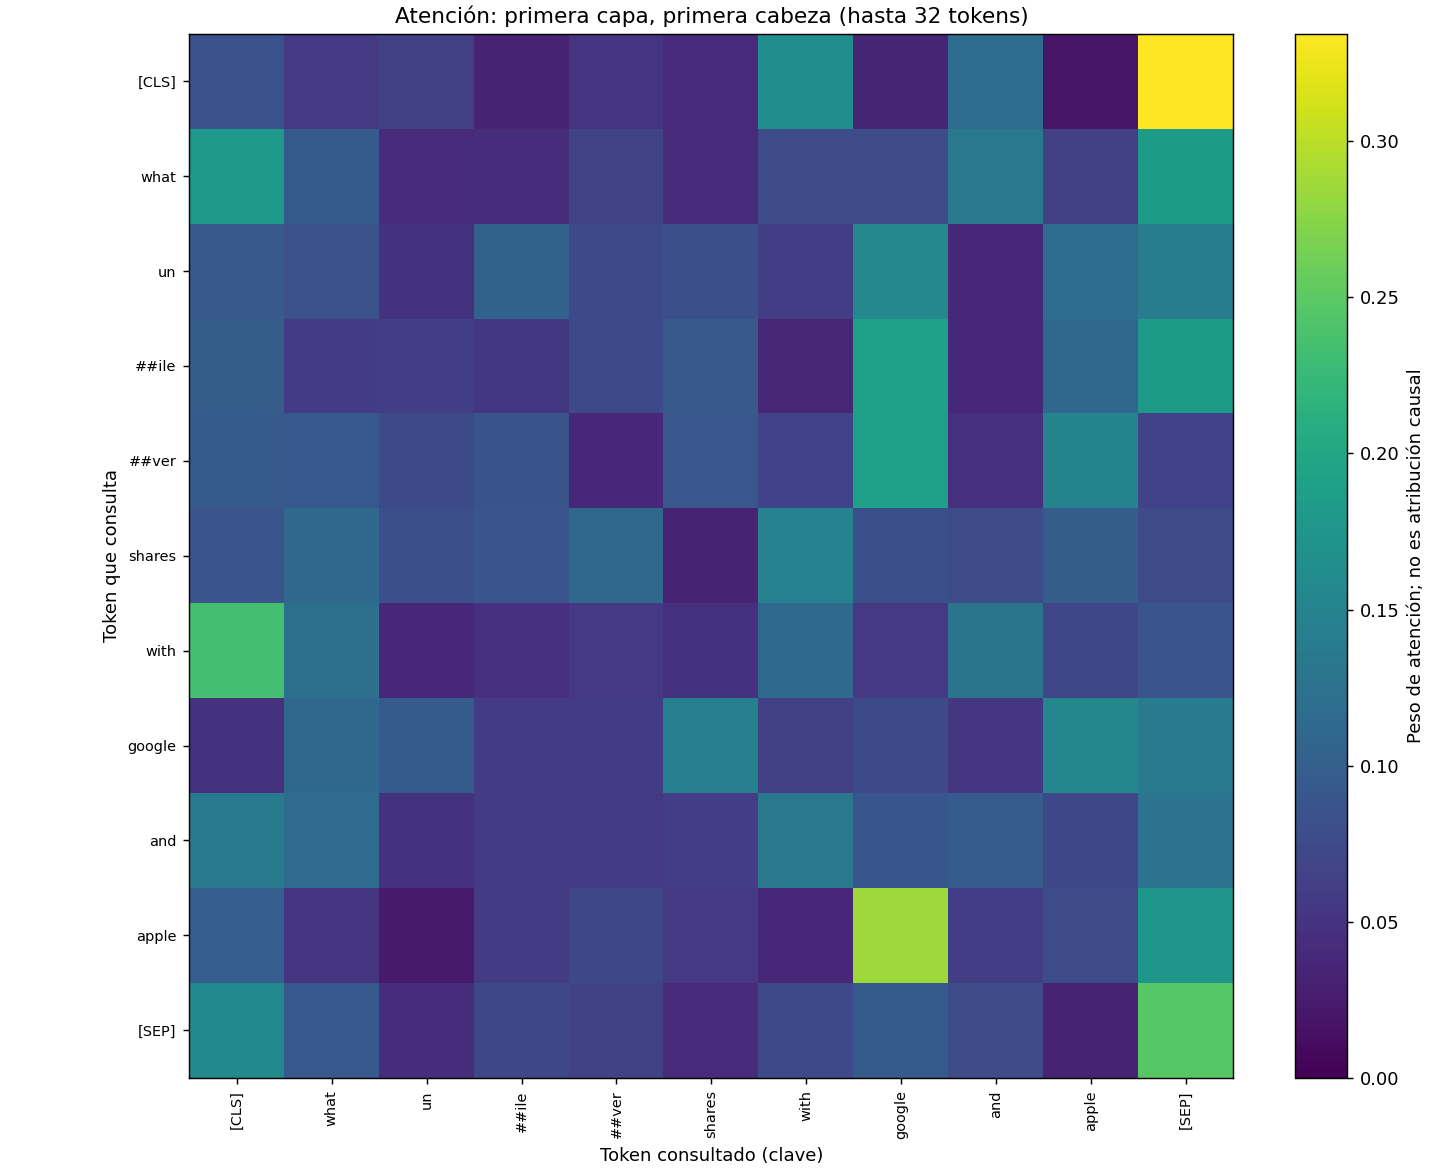

In [8]:
display(Image(filename=str(RUN / 'attention.png')))

**Lectura del gráfico:** fijamos primera capa y primera cabeza, no la más vistosa. El recorte llega hasta 32 tokens; si se recorta una secuencia más larga, las filas visibles pueden no sumar uno. Un peso elevado muestra una relación interna, no demuestra qué palabra causó la decisión.

## 7. Después de la atención

Las cabezas se concatenan y proyectan a 768 dimensiones. Una conexión residual suma la entrada y se normaliza. La red interna aplica **768 → 3072 → GELU → 768**, seguida de otra suma residual y normalización. Se repite en 12 bloques.

El inventario comprueba dónde están los parámetros: no todos pertenecen a atención. La norma de `[CLS]` del gráfico es solo una magnitud, no una medida de importancia ni de comprensión.

,component,parameters
0,embeddings,23837184
1,encoder_01,7087872
2,encoder_02,7087872
3,encoder_03,7087872
4,encoder_04,7087872
5,encoder_05,7087872
6,encoder_06,7087872
7,encoder_07,7087872
8,encoder_08,7087872
9,encoder_09,7087872


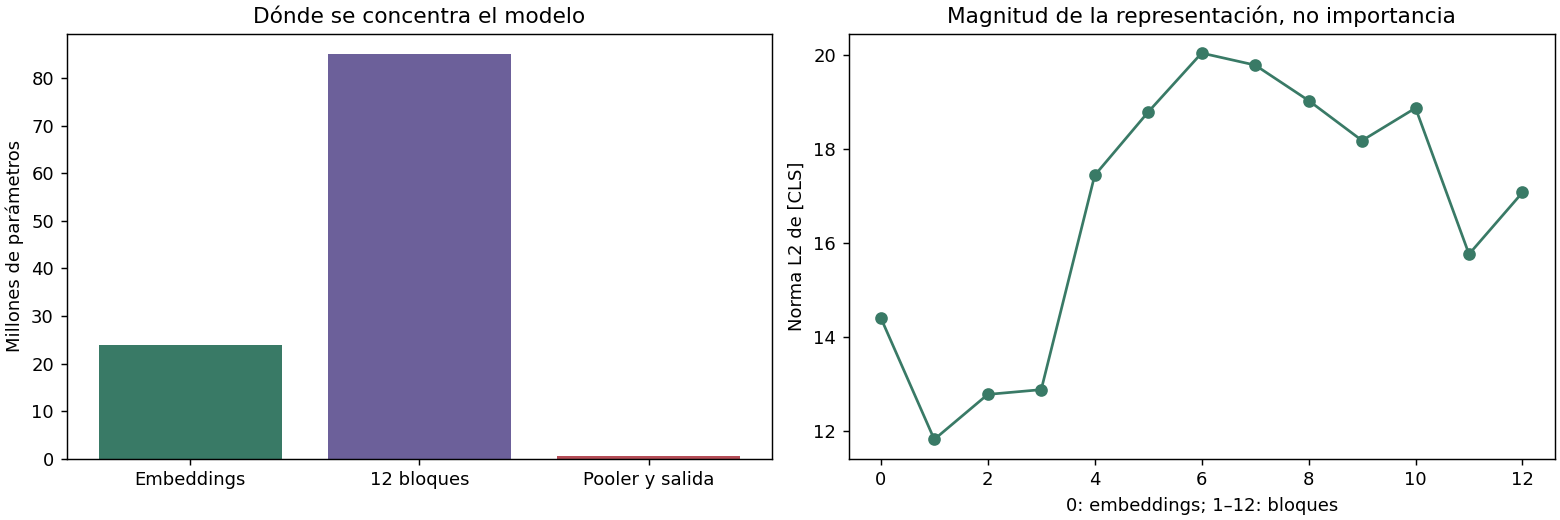

In [9]:
inventory = pd.DataFrame(parameter_inventory(model))
assert inventory.parameters.sum() == sum(p.numel() for p in model.parameters())
display(inventory)
display(Image(filename=str(RUN / 'architecture.png')))

## 8. Pooler, logits y softmax

Leemos `[CLS]` del último bloque, aplicamos una transformación lineal con `tanh` y una capa lineal de tres salidas. Solo entonces se aplica softmax:

$$h_p=\tanh(W_ph_{CLS}+b_p),\quad z=W_ch_p+b_c,\quad p_c=e^{z_c}/\sum_j e^{z_j}.$$

Los logits pueden ser negativos y no suman uno. Las probabilidades sí suman uno, pero no están garantizadas como bien calibradas. El orden de etiquetas procede de la configuración, no de una suposición.

In [10]:
logits = trace['outputs'].logits.detach().cpu()
display(pd.DataFrame(logits.numpy(), columns=[config.id2label[i] for i in range(3)], index=['Titular real', 'Control sintético']))
predictions = pd.DataFrame(prediction_rows(model, trace['probabilities']))
predictions.index = ['Titular real', 'Control sintético']
display(predictions)
assert np.allclose(predictions[['positive', 'negative', 'neutral']].sum(axis=1), 1)
print('s = P(positivo) - P(negativo); no es una probabilidad de subida bursátil.')

,positive,negative,neutral
Titular real,-0.735890,-1.436428,2.484059
Control sintético,2.090783,-2.016636,-1.316756


,positive,negative,neutral,label,score
Titular real,0.037703,0.018713,0.943585,neutral,0.018990
Control sintético,0.952769,0.015673,0.031558,positive,0.937095


s = P(positivo) - P(negativo); no es una probabilidad de subida bursátil.


## 9. Contraste numérico con la biblioteca

Contrastamos embeddings, atención y salida de cada uno de los 12 bloques, pooler, logits y softmax: **28 comprobaciones**. Cada bloque reconstruido parte de su entrada registrada por la biblioteca; medimos error local, no acumulado. Exigimos tolerancias explícitas, no igualdad binaria entre dispositivos.

Esto comprueba que entendemos e implementamos las operaciones inspeccionadas. No demuestra que la predicción lingüística sea correcta.

In [11]:
checks = pd.DataFrame(trace['checks'])
display(checks)
assert checks.passed.all()
assert len(checks) == manifest['checks_passed']
print('Error absoluto máximo:', checks.max_abs_error.max())
solo, _ = encode_texts(tokenizer, ['Profits increased.'])
with torch.no_grad():
    solo_probabilities = model(**solo).logits.softmax(dim=-1)
torch.testing.assert_close(trace['probabilities'][1], solo_probabilities[0], atol=2e-5, rtol=1e-5)
for weights in trace['outputs'].attentions:
    assert torch.count_nonzero(weights[1, :, :, batch['attention_mask'][1] == 0]) == 0
print('Relleno enmascarado y predicción estable al cambiar el lote: verificados.')

,operation,max_abs_error,atol,rtol,passed
0,embeddings,0.000000e+00,0.00002,0.00001,True
1,attention_01,0.000000e+00,0.00002,0.00001,True
2,encoder_01,0.000000e+00,0.00002,0.00001,True
3,attention_02,0.000000e+00,0.00002,0.00001,True
4,encoder_02,0.000000e+00,0.00002,0.00001,True
5,attention_03,0.000000e+00,0.00002,0.00001,True
6,encoder_03,0.000000e+00,0.00002,0.00001,True
7,attention_04,0.000000e+00,0.00002,0.00001,True
8,encoder_04,0.000000e+00,0.00002,0.00001,True
9,attention_05,0.000000e+00,0.00002,0.00001,True


Error absoluto máximo: 3.725290298461914e-09
Relleno enmascarado y predicción estable al cambiar el lote: verificados.


## 10. Conclusiones y límites

- Podemos recorrer y verificar la transformación del texto en tres probabilidades usando los pesos reales de FinBERT.
- El tokenizador, las máscaras, el modo de evaluación y el pooler forman parte de la predicción; no basta con describir solo «BERT + softmax».
- El sentimiento corresponde al texto presentado. No hay una entrada específica entrenada para indicar la empresa objetivo.
- Atención y magnitud de activaciones no son explicaciones causales. Gradientes integrados y perturbaciones se estudiarán en #50.
- No hemos medido precisión lingüística, ajuste adicional, mejora de ROC-AUC ni rentabilidad. Las cuestiones de corpus de entrenamiento y fuga temporal siguen pendientes para la integración.

**Siguiente paso:** evaluar qué comprende de nuestras noticias con anotaciones humanas y análisis de errores (#50), antes de medir utilidad predictiva (#51).

## Fuentes primarias

- [BERT, Devlin et al.](https://aclanthology.org/N19-1423/).
- [Modelo y revisión fijada](https://huggingface.co/ProsusAI/finbert/tree/4556d13015211d73dccd3fdd39d39232506f3e43).
- [Código BERT de Transformers 4.57.6](https://github.com/huggingface/transformers/blob/v4.57.6/src/transformers/models/bert/modeling_bert.py).
- [Attention is not Explanation](https://aclanthology.org/N19-1357/).
- [Guía técnica del proyecto](../docs/finbert_modelo.md), con separación entre antecedentes, artefacto y resultados propios.